# QoS–QoE Unsupervised Learning Analysis
This notebook performs:
1. Data loading
2. Preprocessing
3. Exploratory analysis
4. Elbow method to find optimal K
5. KMeans clustering
6. DBSCAN clustering
7. Cluster QoE analysis
8. Relationship between attributes inside clusters
9. QoE anomaly detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
print('Libraries loaded')

Libraries loaded


## Load Dataset

In [2]:
df = pd.read_csv('../data/engineered_dataset.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (300, 34)


,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter,V_id-video,V_norm-bitrate,V_complexity,V_complexity-class,QoA_resolution,QoA-bitrate,...,screen_width,screen_height,screen_pixels,screen_dim_w,screen_dim_h,screen_area,V_content_Movie,QoD_carte-class_Radeon HD 7610M,QoD_carte-class_VGA compatible controller,QoD-screen_blug-type_LVDS
0,1024,0.0,0.360,0.043,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
1,1024,0.0,0.435,0.071,3,6.422284,5.874106,0,144,79.0,...,1920,1200,2304000,508,317,161036,True,False,False,False
2,1024,0.0,0.403,0.033,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
3,1024,0.0,0.499,0.018,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
4,1024,0.0,0.472,0.034,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True


## Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 34 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   QoS_bandwidth                              300 non-null    int64  
 1   QoS_packet-loss                            300 non-null    float64
 2   QoS_delay                                  300 non-null    float64
 3   QoS_jitter                                 300 non-null    float64
 4   V_id-video                                 300 non-null    int64  
 5   V_norm-bitrate                             300 non-null    float64
 6   V_complexity                               300 non-null    float64
 7   V_complexity-class                         300 non-null    int64  
 8   QoA_resolution                             300 non-null    int64  
 9   QoA-bitrate                                300 non-null    float64
 10  QoA-frame_rate            

In [ ]:
df.describe()

## Missing Values

In [4]:
df.isnull().sum()

QoS_bandwidth                                0
QoS_packet-loss                              0
QoS_delay                                    0
QoS_jitter                                   0
V_id-video                                   0
V_norm-bitrate                               0
V_complexity                                 0
V_complexity-class                           0
QoA_resolution                               0
QoA-bitrate                                  0
QoA-frame_rate                               0
QoA_frame-drop                               0
QoA_audio-rate                               0
QoA_audio-drop                               0
QoD-cpu_mhz-moy                              0
QoD-cpu_mhz-avg                              0
QoD_cpu-nbr                                  0
QoD-cpu_core-nbr                             0
QoD_stepping                                 0
QoD-cpu_bigo-mips                            0
QoD_screen-mhz                               0
QoD-ram_clock

## QoS Features

In [5]:
qos_features = ['QoS_bandwidth','QoS_packet-loss','QoS_delay','QoS_jitter']
X = df[qos_features]
X.head()

,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter
0,1024,0.0,0.360,0.043
1,1024,0.0,0.435,0.071
2,1024,0.0,0.403,0.033
3,1024,0.0,0.499,0.018
4,1024,0.0,0.472,0.034


## Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling done')

Scaling done


## PCA for Visualization

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance:', pca.explained_variance_ratio_)

Explained variance: [0.43914803 0.33397199]


## Elbow Method

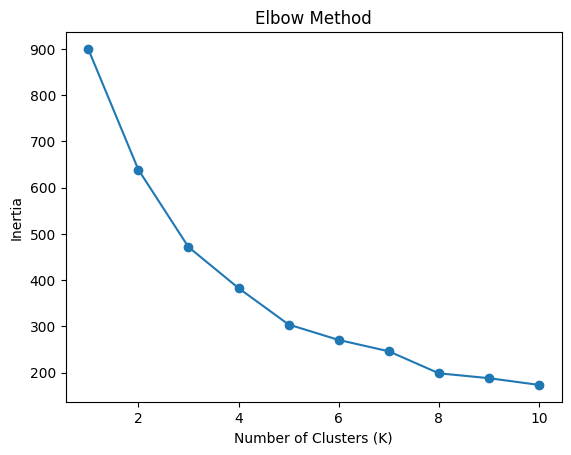

In [8]:
inertia = []
k_values = range(1,11)
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## KMeans Clustering

In [9]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
df[['kmeans_cluster']].head()

,kmeans_cluster
0,4
1,0
2,3
3,3
4,3


## KMeans Visualization

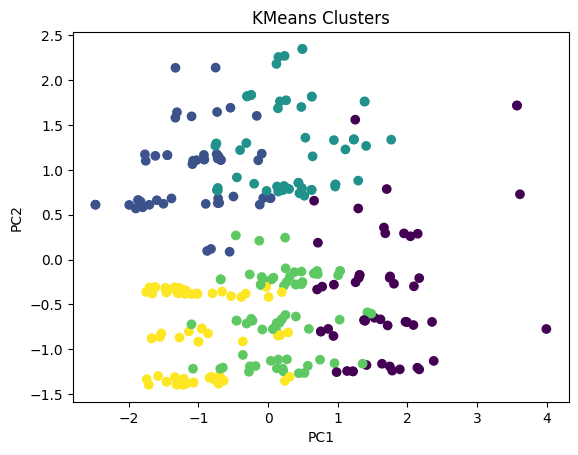

In [10]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters')
plt.show()

## DBSCAN Clustering

In [11]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
df[['dbscan_cluster']].head()

,dbscan_cluster
0,0
1,0
2,0
3,-1
4,0


## DBSCAN Visualization

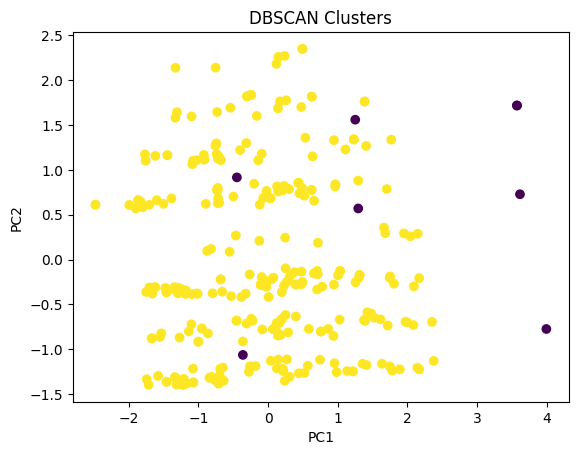

In [12]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['dbscan_cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clusters')
plt.show()

## MOS per Cluster

In [13]:
df.groupby('kmeans_cluster')['MOS'].mean()

kmeans_cluster
0    2.641509
1    4.500000
2    4.464286
3    2.352113
4    2.557143
Name: MOS, dtype: float64

## Relationship Between Attributes in Each Cluster

In [14]:
for cluster in sorted(df['kmeans_cluster'].unique()):
    print('\nCluster', cluster)
    cluster_df = df[df['kmeans_cluster']==cluster]
    print(cluster_df[qos_features + ['MOS']].corr())


Cluster 0
                 QoS_bandwidth  QoS_packet-loss  QoS_delay  QoS_jitter  \
QoS_bandwidth         1.000000              NaN  -0.155310    0.500529   
QoS_packet-loss            NaN              NaN        NaN         NaN   
QoS_delay            -0.155310              NaN   1.000000    0.032432   
QoS_jitter            0.500529              NaN   0.032432    1.000000   
MOS                   0.848399              NaN  -0.106409    0.343225   

                      MOS  
QoS_bandwidth    0.848399  
QoS_packet-loss       NaN  
QoS_delay       -0.106409  
QoS_jitter       0.343225  
MOS              1.000000  

Cluster 1
                 QoS_bandwidth  QoS_packet-loss  QoS_delay  QoS_jitter  \
QoS_bandwidth         1.000000              NaN   0.180846    0.076840   
QoS_packet-loss            NaN              NaN        NaN         NaN   
QoS_delay             0.180846              NaN   1.000000    0.391185   
QoS_jitter            0.076840              NaN   0.391185    1.00000

## QoE Anomaly Detection

In [15]:
cluster_mean = df.groupby('kmeans_cluster')['MOS'].transform('mean')
df['qoe_anomaly'] = df['MOS'] < (0.5 * cluster_mean)
print('Number of anomalies:', df['qoe_anomaly'].sum())

Number of anomalies: 38


## Anomaly Visualization

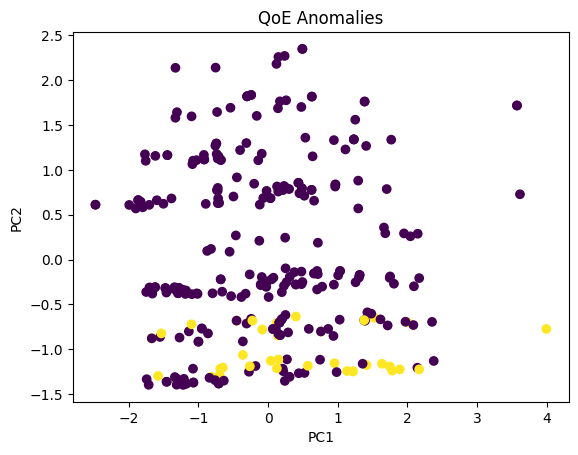

In [16]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['qoe_anomaly'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('QoE Anomalies')
plt.show()